# CS3807 – Deep Learning Lab | Experiment 7
## End-to-End Study of Autoencoders, Convolutional AE, Denoising AE and Variational AE

**Dataset:** MNIST (10,000 train / 2,000 test subset) | **Framework:** TensorFlow / Keras

Run the cells **top to bottom** (Runtime → Run all). All numbers, plots and tables come from your own execution. Every figure is also saved in `figures/` and zipped for download in the last code cell.

Sections: 1) Setup · 2) FC-AE · 3) CAE · 4) FC vs CAE · 5) Denoising CAE · 6) Latent-dimension study · 7) VAE · 8) Error distribution + high-error images · 9) Consolidated results · 10) Inference templates · 11) Discussion answers

In [1]:
# ============================ 1. SETUP ============================
import os, time, random, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from skimage.metrics import structural_similarity as ssim_fn

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
os.makedirs("figures", exist_ok=True)
pd.set_option("display.float_format", lambda v: f"{v:.5f}")
print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0 | Keras: 3.13.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Data: load MNIST, normalise to [0,1], take the lab subset
Train = 9,000 images, Validation = 1,000 images (both carved out of the 10,000 training subset), Test = 2,000 images (never used for training). Labels are used **only** for visualisation.

In [2]:
(x_tr_all, y_tr_all), (x_te_all, y_te_all) = keras.datasets.mnist.load_data()

x_tr_all = (x_tr_all[:10000].astype("float32") / 255.0)[..., None]   # (10000,28,28,1)
y_tr_all = y_tr_all[:10000]
x_test   = (x_te_all[:2000].astype("float32") / 255.0)[..., None]    # (2000,28,28,1)
y_test   = y_te_all[:2000]

x_train, x_val = x_tr_all[:9000], x_tr_all[9000:]
y_train, y_val = y_tr_all[:9000], y_tr_all[9000:]

flat = lambda a: a.reshape(len(a), 784)
print("train", x_train.shape, "| val", x_val.shape, "| test", x_test.shape, "| range", x_train.min(), x_train.max())

# Shared config (as per lab sheet)
EPOCHS, BATCH, LR = 20, 128, 1e-3

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
train (9000, 28, 28, 1) | val (1000, 28, 28, 1) | test (2000, 28, 28, 1) | range 0.0 1.0


In [3]:
# ---------------- Helper functions: metrics, plotting, training ----------------
def per_image_mse(x, xh): return np.mean((x - xh) ** 2, axis=(1, 2, 3))
def per_image_mae(x, xh): return np.mean(np.abs(x - xh), axis=(1, 2, 3))
def per_image_ssim(x, xh):
    return np.array([ssim_fn(a[..., 0], b[..., 0], data_range=1.0) for a, b in zip(x, xh)])

def evaluate_recon(x, xh):
    """Test MSE, MAE (over all pixels) and mean SSIM."""
    return {"MSE": float(np.mean((x - xh) ** 2)),
            "MAE": float(np.mean(np.abs(x - xh))),
            "SSIM": float(per_image_ssim(x, xh).mean())}

def finish(name):
    plt.tight_layout()
    plt.savefig(f"figures/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

def show_rows(rows, labels, n=10, name=None, title=None, cmaps=None):
    """Grid: each row is one set of images (e.g. original / reconstruction / error)."""
    cmaps = cmaps or ["gray"] * len(rows)
    fig, axes = plt.subplots(len(rows), n, figsize=(1.35 * n + 1.5, 1.45 * len(rows) + 0.5), squeeze=False)
    for r, (imgs, lab, cm) in enumerate(zip(rows, labels, cmaps)):
        for c in range(n):
            ax = axes[r, c]
            ax.imshow(np.squeeze(imgs[c]), cmap=cm, vmin=0, vmax=1)
            ax.set_xticks([]); ax.set_yticks([])
            for s in ax.spines.values(): s.set_visible(False)
        axes[r, 0].text(-0.15, 0.5, lab, transform=axes[r, 0].transAxes, ha="right", va="center", fontsize=10)
    if title: fig.suptitle(title, y=1.02)
    finish(name or "grid")

def plot_history(hist, pairs, name, suptitle):
    """pairs = list of (train_key, val_key, ylabel). One separate axis per quantity."""
    fig, axes = plt.subplots(1, len(pairs), figsize=(5.2 * len(pairs), 3.8))
    axes = np.atleast_1d(axes)
    for ax, (tk, vk, yl) in zip(axes, pairs):
        ax.plot(hist.history[tk], label="Training"); ax.plot(hist.history[vk], label="Validation")
        ax.set_xlabel("Epoch"); ax.set_ylabel(yl); ax.set_title(yl); ax.legend(); ax.grid(alpha=.3)
    fig.suptitle(suptitle, y=1.03)
    finish(name)

def compile_fit(model, xin, xtgt, xvin, xvtgt, epochs=EPOCHS, bs=BATCH, verbose=2):
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=LR), loss="binary_crossentropy", metrics=[keras.metrics.MeanSquaredError(name="mse")])
    t0 = time.time()
    hist = model.fit(xin, xtgt, validation_data=(xvin, xvtgt), epochs=epochs,
                     batch_size=bs, shuffle=True, verbose=verbose)
    return hist, time.time() - t0

results = {}   # collects everything for the consolidated table

---
# 2. Fully Connected Autoencoder
Architecture: 784 → 128 → 32 → **16 (latent)** → 32 → 128 → 784. ReLU in hidden layers, sigmoid output, Adam (1e-3), batch 128, 20 epochs, binary cross-entropy.

In [4]:
def build_fc_ae(latent_dim=16):
    inp = keras.Input((784,))
    h = layers.Dense(128, activation="relu")(inp)
    h = layers.Dense(32, activation="relu")(h)
    z = layers.Dense(latent_dim, name="latent")(h)             # linear latent code
    h = layers.Dense(32, activation="relu")(z)
    h = layers.Dense(128, activation="relu")(h)
    out = layers.Dense(784, activation="sigmoid")(h)
    return keras.Model(inp, out, name=f"fc_ae_z{latent_dim}")

tf.random.set_seed(SEED)
fc_ae = build_fc_ae(16)
fc_ae.summary()
hist_fc, t_fc = compile_fit(fc_ae, flat(x_train), flat(x_train), flat(x_val), flat(x_val))
print(f"\nTraining time: {t_fc:.1f}s")

Model: "fc_ae_z16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
71/71 - 5s - 76ms/step - loss: 0.3516 - mse: 0.0961 - val_loss: 0.2606 - val_mse: 0.0655
Epoch 2/20
71/71 - 0s - 4ms/step - loss: 0.2299 - mse: 0.0558 - val_loss: 0.2075 - val_mse: 0.0482
Epoch 3/20
71/71 - 0s - 4ms/step - loss: 0.1924 - mse: 0.0436 - val_loss: 0.1845 - val_mse: 0.0406
Epoch 4/20
71/71 - 0s - 4ms/step - loss: 0.1720 - mse: 0.0367 - val_loss: 0.1697 - val_mse: 0.0356
Epoch 5/20
71/71 - 0s - 4ms/step - loss: 0.1612 - mse: 0.0331 - val_loss: 0.1615 - val_mse: 0.0328
Epoch 6/20
71/71 - 0s - 4ms/step - loss: 0.1529 - mse: 0.0302 - val_loss: 0.1545 - val_mse: 0.0305
Epoch 7/20
71/71 - 0s - 4ms/step - loss: 0.1460 - mse: 0.0279 - val_loss: 0.1488 - val_mse: 0.0285
Epoch 8/20
71/71 - 0s - 4ms/step - loss: 0.1410 - mse: 0.0262 - val_loss: 0.1448 - val_mse: 0.0272
Epoch 9/20
71/71 - 0s - 4ms/step - loss: 0.1375 - mse: 0.0250 - val_loss: 0.1420 - val_mse: 0.0263
Epoch 10/20
71/71 - 0s - 4ms/step - loss: 0.1348 - mse: 0.0241 - val_loss: 0.1398 - val_mse: 0.0255
Epoch 11

=== FC-AE test metrics ===
   Metric   Value
 Test MSE 0.02047
 Test MAE 0.05513
Mean SSIM 0.75865


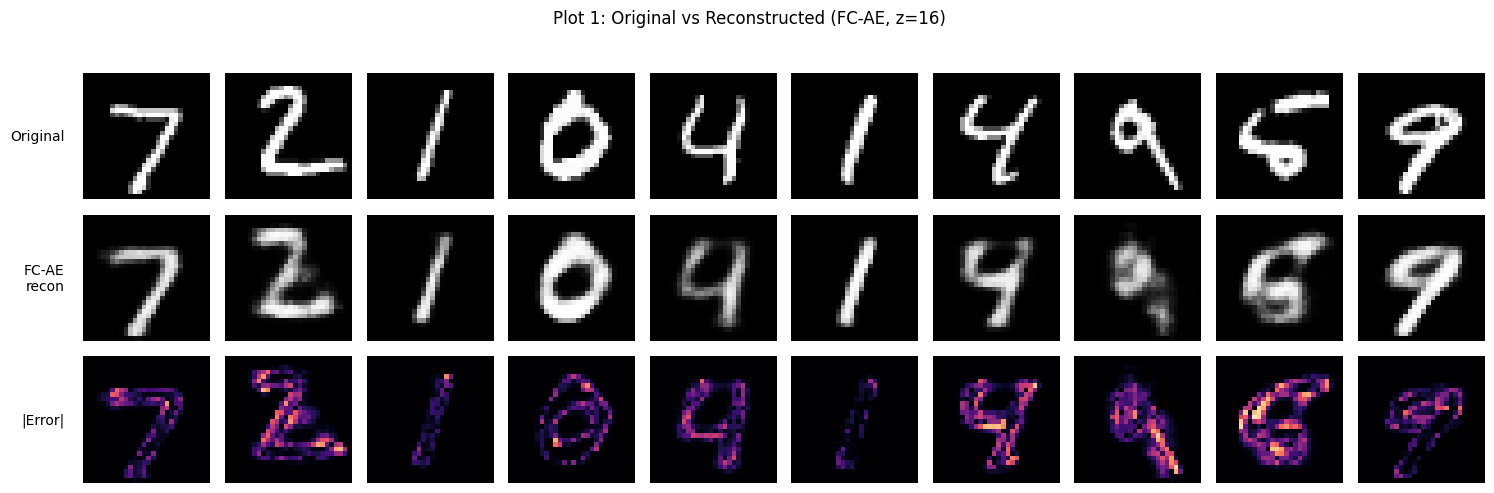

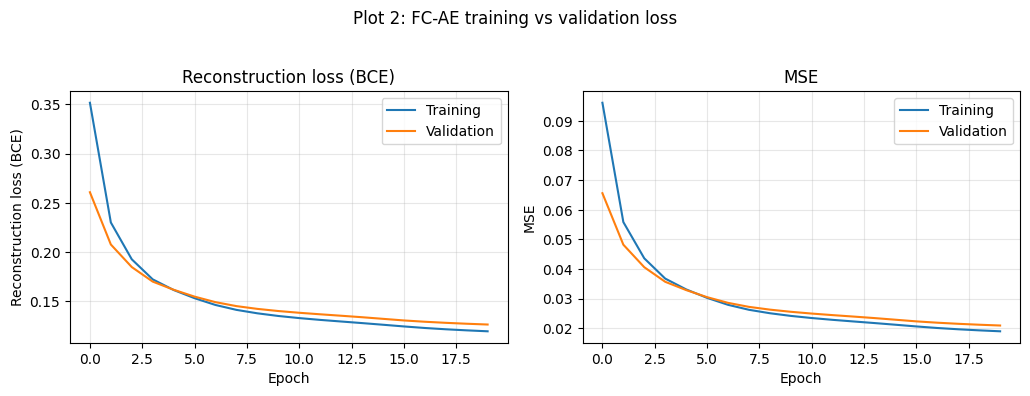

Final train BCE = 0.1192 | final val BCE = 0.1261 | gap = 0.0069
Best val epoch: 20 of 20 (if this is much earlier than the last epoch and the gap grows -> overfitting)


In [5]:
recon_fc = fc_ae.predict(flat(x_test), verbose=0).reshape(-1, 28, 28, 1)
m = evaluate_recon(x_test, recon_fc)
results["FC Autoencoder"] = {**m, "Parameters": fc_ae.count_params(), "Time (s)": t_fc}

print("=== FC-AE test metrics ===")
print(pd.DataFrame({"Metric": ["Test MSE", "Test MAE", "Mean SSIM"], "Value": [m["MSE"], m["MAE"], m["SSIM"]]}).to_string(index=False))

# ---- Plot 1: Original vs Reconstruction (+ error map) ----
n = 10
show_rows([x_test[:n], recon_fc[:n], np.abs(x_test[:n] - recon_fc[:n])],
          ["Original", "FC-AE\nrecon", "|Error|"], n=n, name="plot1_original_vs_recon",
          title="Plot 1: Original vs Reconstructed (FC-AE, z=16)", cmaps=["gray", "gray", "magma"])

# ---- Plot 2: Training & validation reconstruction loss ----
plot_history(hist_fc, [("loss", "val_loss", "Reconstruction loss (BCE)"), ("mse", "val_mse", "MSE")],
             "plot2_fc_ae_loss", "Plot 2: FC-AE training vs validation loss")
gap = hist_fc.history["val_loss"][-1] - hist_fc.history["loss"][-1]
print(f"Final train BCE = {hist_fc.history['loss'][-1]:.4f} | final val BCE = {hist_fc.history['val_loss'][-1]:.4f} | gap = {gap:.4f}")
print("Best val epoch:", int(np.argmin(hist_fc.history['val_loss'])) + 1, "of", EPOCHS,
      "(if this is much earlier than the last epoch and the gap grows -> overfitting)")

---
# 3. Convolutional Autoencoder
Input 28×28×1 → Conv32 → MaxPool → Conv64 → MaxPool (7×7×64 latent feature map) → Conv64 → UpSample → Conv32 → UpSample → Conv1 (sigmoid).

In [6]:
def build_cae():
    inp = keras.Input((28, 28, 1))
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same", name="latent_map")(x)   # 7x7x64
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    out = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)
    return keras.Model(inp, out, name="cae")

tf.random.set_seed(SEED)
cae = build_cae()
cae.summary()
hist_cae, t_cae = compile_fit(cae, x_train, x_train, x_val, x_val)
recon_cae = cae.predict(x_test, verbose=0)
m = evaluate_recon(x_test, recon_cae)
results["Conv. Autoencoder"] = {**m, "Parameters": cae.count_params(), "Time (s)": t_cae}
print(f"\nCAE latent map = 7x7x64 = {7*7*64} values (vs 784 input): it is a spatial feature map, not a bottleneck vector.")

Model: "cae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_map (MaxPooling2D)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
71/71 - 9s - 130ms/step - loss: 0.2618 - mse: 0.0662 - val_loss: 0.1141 - val_mse: 0.0172
Epoch 2/20
71/71 - 1s - 8ms/step - loss: 0.0958 - mse: 0.0113 - val_loss: 0.0900 - val_mse: 0.0092
Epoch 3/20
71/71 - 1s - 7ms/step - loss: 0.0847 - mse: 0.0077 - val_loss: 0.0850 - val_mse: 0.0077
Epoch 4/20
71/71 - 1s - 8ms/step - loss: 0.0802 - mse: 0.0063 - val_loss: 0.0804 - val_mse: 0.0062
Epoch 5/20
71/71 - 1s - 8ms/step - loss: 0.0772 - mse: 0.0053 - val_loss: 0.0775 - val_mse: 0.0052
Epoch 6/20
71/71 - 1s - 8ms/step - loss: 0.0754 - mse: 0.0048 - val_loss: 0.0762 - val_mse: 0.0047
Epoch 7/20
71/71 - 1s - 8ms/step - loss: 0.0742 - mse: 0.0044 - val_loss: 0.0752 - val_mse: 0.0044
Epoch 8/20
71/71 - 1s - 7ms/step - loss: 0.0732 - mse: 0.0041 - val_loss: 0.0744 - val_mse: 0.0042
Epoch 9/20
71/71 - 1s - 8ms/step - loss: 0.0725 - mse: 0.0039 - val_loss: 0.0737 - val_mse: 0.0040
Epoch 10/20
71/71 - 1s - 7ms/step - loss: 0.0718 - mse: 0.0037 - val_loss: 0.0730 - val_mse: 0.0038
Epoch 1

---
# 4. FC-AE vs CAE

=== Table: Fully Connected AE vs Convolutional AE (test set) ===


,MSE,MAE,SSIM,Parameters
FC Autoencoder,0.02047,0.05513,0.75865,211040
Conv. Autoencoder,0.00259,0.01508,0.97371,74497


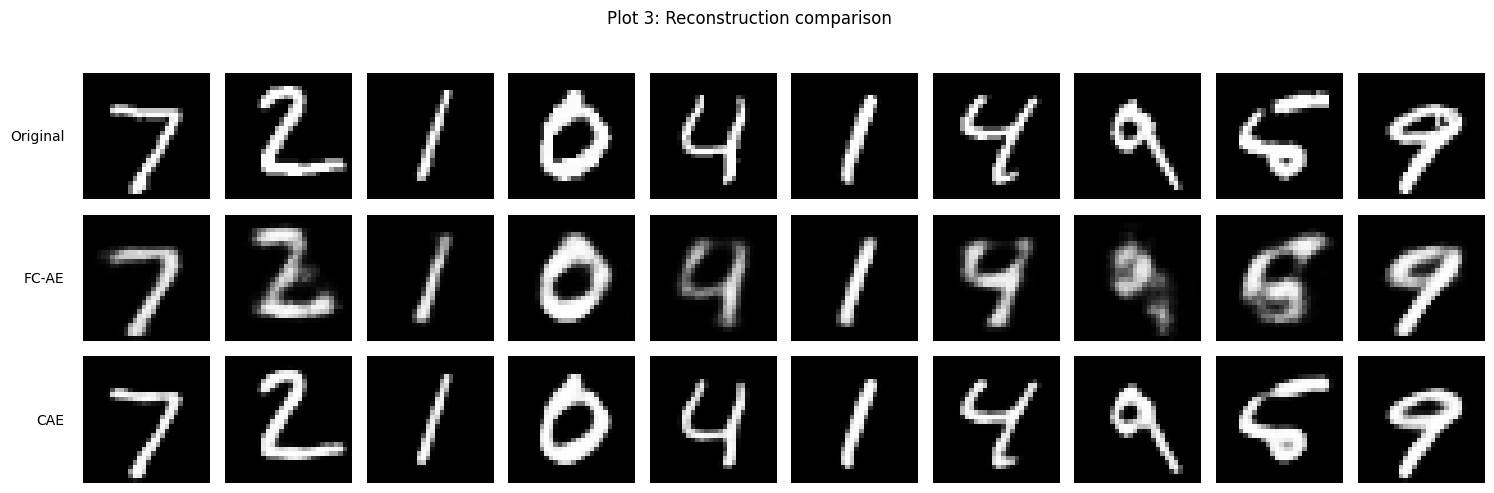

In [7]:
comp = pd.DataFrame({k: results[k] for k in ["FC Autoencoder", "Conv. Autoencoder"]}).T
comp = comp[["MSE", "MAE", "SSIM", "Parameters"]]
comp["Parameters"] = comp["Parameters"].astype(int)
print("=== Table: Fully Connected AE vs Convolutional AE (test set) ===")
display(comp)

# ---- Plot 3: Original -> FC-AE -> CAE ----
show_rows([x_test[:10], recon_fc[:10], recon_cae[:10]],
          ["Original", "FC-AE", "CAE"], n=10, name="plot3_fc_vs_cae",
          title="Plot 3: Reconstruction comparison")

---
# 5. Denoising Convolutional Autoencoder
Noise types: **Gaussian** (σ ∈ {0.1, 0.2, 0.3}, clipped to [0,1]) and **Salt-and-Pepper** (p ∈ {0.05, 0.10, 0.20}).
The DAE is trained on a mix of both noise types with random per-image levels (σ ∈ [0.1,0.3], p ∈ [0.05,0.2]); the **target is always the clean image**.

In [8]:
rng = np.random.default_rng(SEED)

def add_gaussian(x, sigma, rng):
    """x~ = clip(x + N(0, sigma^2), 0, 1). sigma may be scalar or per-image array."""
    return np.clip(x + rng.normal(0.0, 1.0, x.shape) * sigma, 0.0, 1.0).astype("float32")

def add_salt_pepper(x, p, rng):
    """Fraction p of pixels corrupted: half set to 0 (pepper), half to 1 (salt)."""
    u = rng.random(x.shape); out = x.copy()
    out[u < p / 2] = 0.0
    out[(u >= p / 2) & (u < p)] = 1.0
    return out.astype("float32")

def make_noisy_set(x, rng):
    n = len(x)
    sig = rng.uniform(0.10, 0.30, (n, 1, 1, 1))
    p   = rng.uniform(0.05, 0.20, (n, 1, 1, 1))
    xn = np.concatenate([add_gaussian(x, sig, rng), add_salt_pepper(x, p, rng)])
    xc = np.concatenate([x, x])                      # clean targets
    return xn, xc

xn_train, xc_train = make_noisy_set(x_train, rng)
xn_val,   xc_val   = make_noisy_set(x_val, rng)
print("noisy train:", xn_train.shape, "| noisy val:", xn_val.shape)

tf.random.set_seed(SEED)
dcae = build_cae(); dcae._name = "denoising_cae"
hist_dcae, t_dcae = compile_fit(dcae, xn_train, xc_train, xn_val, xc_val)

noisy train: (18000, 28, 28, 1) | noisy val: (2000, 28, 28, 1)
Epoch 1/20
141/141 - 9s - 66ms/step - loss: 0.1882 - mse: 0.0405 - val_loss: 0.1093 - val_mse: 0.0156
Epoch 2/20
141/141 - 1s - 7ms/step - loss: 0.0963 - mse: 0.0113 - val_loss: 0.0947 - val_mse: 0.0104
Epoch 3/20
141/141 - 1s - 7ms/step - loss: 0.0895 - mse: 0.0091 - val_loss: 0.0898 - val_mse: 0.0088
Epoch 4/20
141/141 - 1s - 7ms/step - loss: 0.0863 - mse: 0.0080 - val_loss: 0.0867 - val_mse: 0.0078
Epoch 5/20
141/141 - 1s - 9ms/step - loss: 0.0840 - mse: 0.0073 - val_loss: 0.0851 - val_mse: 0.0073
Epoch 6/20
141/141 - 1s - 7ms/step - loss: 0.0824 - mse: 0.0068 - val_loss: 0.0839 - val_mse: 0.0069
Epoch 7/20
141/141 - 1s - 7ms/step - loss: 0.0813 - mse: 0.0065 - val_loss: 0.0828 - val_mse: 0.0066
Epoch 8/20
141/141 - 1s - 7ms/step - loss: 0.0804 - mse: 0.0062 - val_loss: 0.0816 - val_mse: 0.0063
Epoch 9/20
141/141 - 1s - 7ms/step - loss: 0.0797 - mse: 0.0060 - val_loss: 0.0807 - val_mse: 0.0060
Epoch 10/20
141/141 - 1s - 

=== Noise level vs reconstruction quality (vs CLEAN test images) ===


,Noise,Level,MSE (noisy),MSE (denoised),MAE (noisy),MAE (denoised),SSIM (noisy),SSIM (denoised)
0,Gaussian,0.10000,0.00543,0.00329,0.04403,0.01729,0.67891,0.96219
1,Gaussian,0.20000,0.02122,0.00437,0.08660,0.02057,0.59388,0.94717
2,Gaussian,0.30000,0.04670,0.00657,0.12806,0.02655,0.50930,0.91115
3,Salt & Pepper,0.05000,0.02405,0.00369,0.02495,0.01802,0.70835,0.95736
4,Salt & Pepper,0.10000,0.04823,0.00464,0.05010,0.02040,0.57893,0.94517
5,Salt & Pepper,0.20000,0.09618,0.00763,0.09986,0.02731,0.44689,0.90225


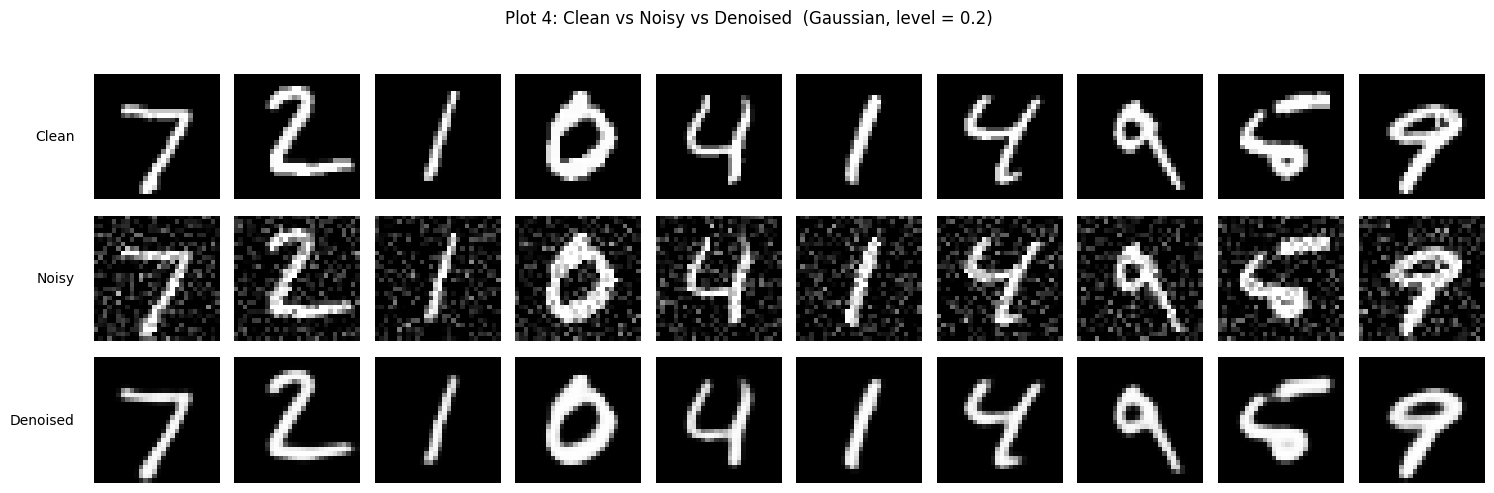

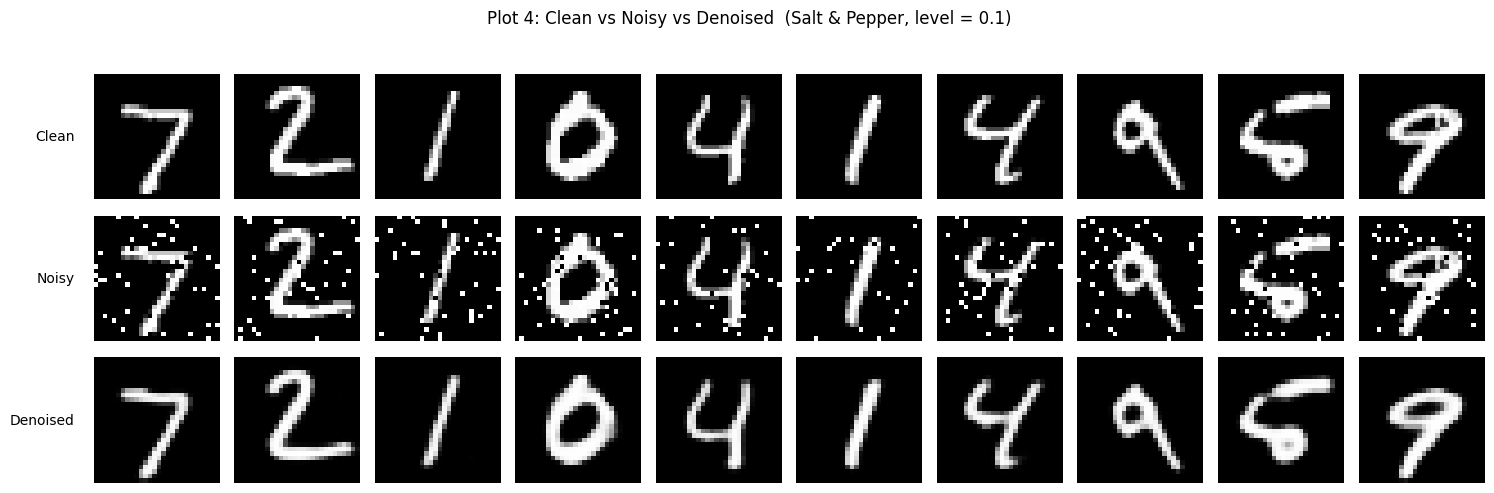

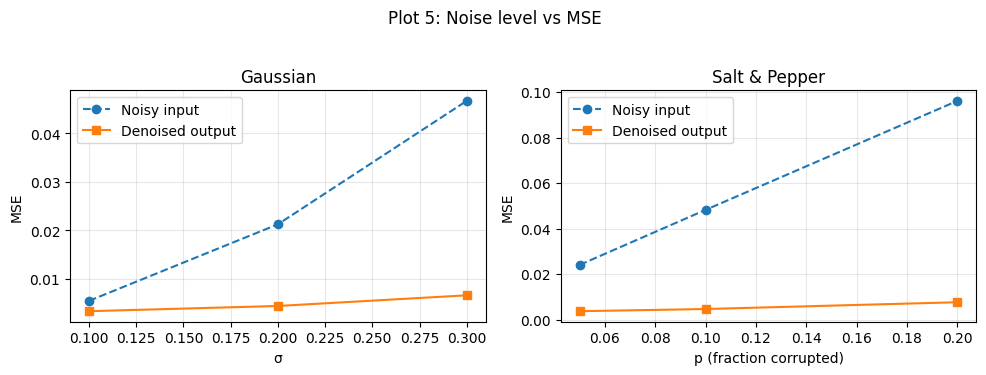

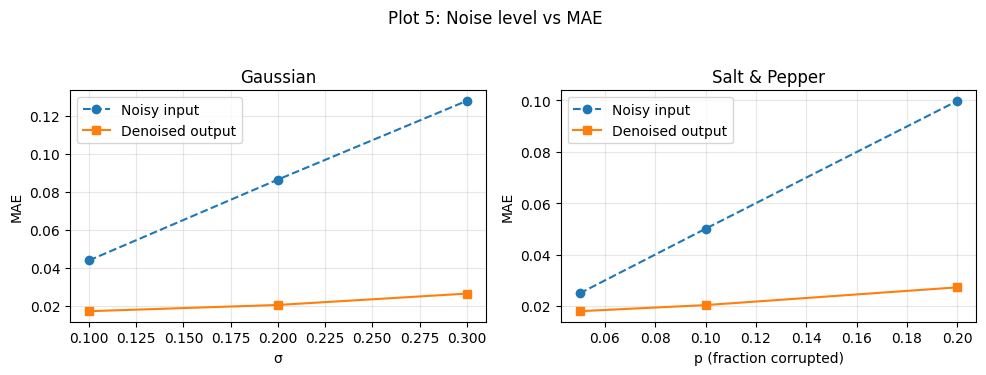

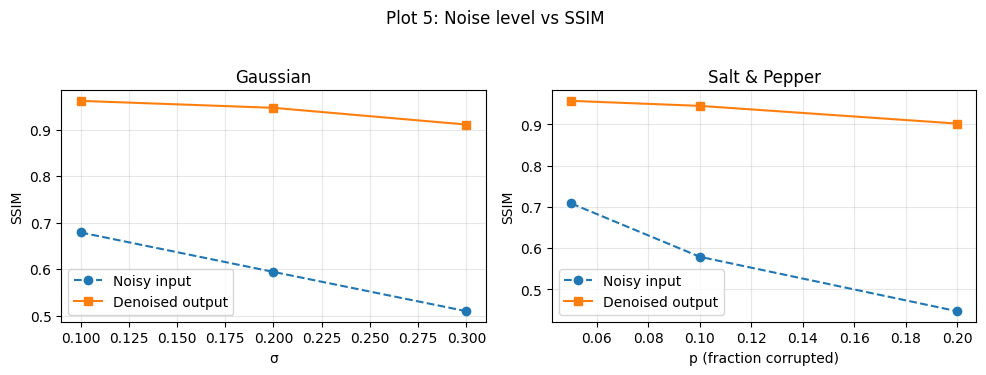

Denoising CAE row uses Gaussian sigma=0.2 noisy test images -> clean targets.


In [9]:
# ---- Evaluate at every noise level (fixed noisy test sets) ----
levels = {"Gaussian": [0.1, 0.2, 0.3], "Salt & Pepper": [0.05, 0.10, 0.20]}
noisy_test, rows = {}, []
for kind, lvls in levels.items():
    for l in lvls:
        xn = add_gaussian(x_test, l, rng) if kind == "Gaussian" else add_salt_pepper(x_test, l, rng)
        xd = dcae.predict(xn, verbose=0)
        noisy_test[(kind, l)] = (xn, xd)
        mn, md = evaluate_recon(x_test, xn), evaluate_recon(x_test, xd)
        rows.append({"Noise": kind, "Level": l,
                     "MSE (noisy)": mn["MSE"], "MSE (denoised)": md["MSE"],
                     "MAE (noisy)": mn["MAE"], "MAE (denoised)": md["MAE"],
                     "SSIM (noisy)": mn["SSIM"], "SSIM (denoised)": md["SSIM"]})
noise_df = pd.DataFrame(rows)
print("=== Noise level vs reconstruction quality (vs CLEAN test images) ===")
display(noise_df)

# ---- Plot 4: Clean | Noisy | Denoised ----
for kind, l in [("Gaussian", 0.2), ("Salt & Pepper", 0.10)]:
    xn, xd = noisy_test[(kind, l)]
    show_rows([x_test[:10], xn[:10], xd[:10]], ["Clean", "Noisy", "Denoised"], n=10,
              name=f"plot4_denoise_{kind.split()[0].lower()}_{l}",
              title=f"Plot 4: Clean vs Noisy vs Denoised  ({kind}, level = {l})")

# ---- Plot 5: Noise level vs MSE / MAE / SSIM (separate figure per metric) ----
for metric in ["MSE", "MAE", "SSIM"]:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
    for ax, kind in zip(axes, levels):
        d = noise_df[noise_df["Noise"] == kind]
        ax.plot(d["Level"], d[f"{metric} (noisy)"], "o--", label="Noisy input")
        ax.plot(d["Level"], d[f"{metric} (denoised)"], "s-", label="Denoised output")
        ax.set_xlabel("σ" if kind == "Gaussian" else "p (fraction corrupted)")
        ax.set_ylabel(metric); ax.set_title(kind); ax.grid(alpha=.3); ax.legend()
    fig.suptitle(f"Plot 5: Noise level vs {metric}", y=1.03)
    finish(f"plot5_noise_vs_{metric.lower()}")

# Denoising CAE row for the results tables (Gaussian sigma = 0.2 test inputs)
xn02, xd02 = noisy_test[("Gaussian", 0.2)]
results["Denoising CAE"] = {**evaluate_recon(x_test, xd02), "Parameters": dcae.count_params(), "Time (s)": t_dcae}
print("Denoising CAE row uses Gaussian sigma=0.2 noisy test images -> clean targets.")

---
# 6. Additional Latent-Dimension Study (FC-AE, dz ∈ {2, 8, 16, 32})

dz= 2 done  (MSE=0.04634, SSIM=0.4481, 11s)
dz= 8 done  (MSE=0.02731, SSIM=0.6835, 10s)
dz=16 done  (MSE=0.02095, SSIM=0.7520, 10s)
dz=32 done  (MSE=0.01966, SSIM=0.7669, 10s)


,Latent Dimension,MSE,SSIM,Parameters
0,2,0.04634,0.44814,210130
1,8,0.02731,0.68355,210520
2,16,0.02095,0.75195,211040
3,32,0.01966,0.76689,212080


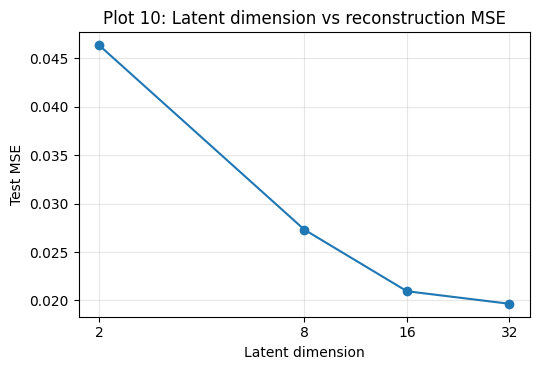

In [10]:
lat_rows = []
for dz in [2, 8, 16, 32]:
    tf.random.set_seed(SEED)
    mdl = build_fc_ae(dz)
    h, t = compile_fit(mdl, flat(x_train), flat(x_train), flat(x_val), flat(x_val), verbose=0)
    xh = mdl.predict(flat(x_test), verbose=0).reshape(-1, 28, 28, 1)
    mm = evaluate_recon(x_test, xh)
    lat_rows.append({"Latent Dimension": dz, "MSE": mm["MSE"], "SSIM": mm["SSIM"], "Parameters": mdl.count_params()})
    print(f"dz={dz:>2} done  (MSE={mm['MSE']:.5f}, SSIM={mm['SSIM']:.4f}, {t:.0f}s)")
lat_df = pd.DataFrame(lat_rows)
display(lat_df)

# ---- Plot 10: Latent dimension vs MSE ----
fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.plot(lat_df["Latent Dimension"], lat_df["MSE"], "o-")
ax.set_xscale("log", base=2); ax.set_xticks(lat_df["Latent Dimension"]); ax.set_xticklabels(lat_df["Latent Dimension"])
ax.set_xlabel("Latent dimension"); ax.set_ylabel("Test MSE"); ax.grid(alpha=.3)
ax.set_title("Plot 10: Latent dimension vs reconstruction MSE")
finish("plot10_latent_dim_vs_mse")

---
# 7. Variational Autoencoder (latent dimension = 2)
Encoder → (μ, log σ²) → reparameterisation `z = μ + σ ⊙ ε` → Decoder.
Loss = BCE reconstruction (summed over pixels) + KL(q(z|x) ‖ N(0, I)), both averaged over the batch.

In [11]:
# ---- VAE: 2-D latent space ----
LATENT_VAE = 2

class Sampling(layers.Layer):
    """Reparameterisation: z = mu + exp(0.5 * log_var) * epsilon."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


def build_vae_encoder(latent_dim=LATENT_VAE):
    inp = keras.Input(shape=(28, 28, 1), name="encoder_input")
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = layers.MaxPooling2D(2, padding="same")(x)       # 14x14x32
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)       # 7x7x64
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)

    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling(name="z")([z_mean, z_log_var])

    return keras.Model(inp, [z_mean, z_log_var, z], name="vae_encoder")


def build_vae_decoder(latent_dim=LATENT_VAE):
    inp = keras.Input(shape=(latent_dim,), name="decoder_input")
    x = layers.Dense(7 * 7 * 64, activation="relu")(inp)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
    out = layers.Conv2D(1, 3, padding="same", activation="sigmoid")(x)
    return keras.Model(inp, out, name="vae_decoder")


class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta

        self.total_tracker = keras.metrics.Mean(name="total_loss")
        self.rec_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_tracker, self.rec_tracker, self.kl_tracker]

    def _compute_losses(self, x, training=False):
        z_mean, z_log_var, z = self.encoder(x, training=training)
        xh = self.decoder(z, training=training)

        # BCE summed over all pixels, then averaged over the batch.
        xh_clip = tf.clip_by_value(xh, 1e-7, 1.0 - 1e-7)
        bce = -(x * tf.math.log(xh_clip) +
                (1.0 - x) * tf.math.log(1.0 - xh_clip))
        rec = tf.reduce_mean(tf.reduce_sum(bce, axis=[1, 2, 3]))

        kl_per_image = -0.5 * tf.reduce_sum(
            1.0 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
            axis=1
        )
        kl = tf.reduce_mean(kl_per_image)

        return rec, kl

    def train_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data

        with tf.GradientTape() as tape:
            rec, kl = self._compute_losses(x, training=True)
            total = rec + self.beta * kl

        grads = tape.gradient(total, self.trainable_weights)
        self.optimizer.apply_gradients(
            [(g, v) for g, v in zip(grads, self.trainable_weights) if g is not None]
        )

        self.total_tracker.update_state(total)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data

        rec, kl = self._compute_losses(x, training=False)
        total = rec + self.beta * kl

        self.total_tracker.update_state(total)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)

        return {m.name: m.result() for m in self.metrics}


tf.random.set_seed(SEED)
encoder = build_vae_encoder(LATENT_VAE)
decoder = build_vae_decoder(LATENT_VAE)
vae = VAE(encoder, decoder, beta=1.0, name="vae")

encoder.summary()
decoder.summary()

vae.compile(optimizer=keras.optimizers.Adam(learning_rate=LR))

t0 = time.time()
hist_vae = vae.fit(
    x_train,
    validation_data=(x_val, None),
    epochs=EPOCHS,
    batch_size=BATCH,
    shuffle=True,
    verbose=2
)
t_vae = time.time() - t0

print(f"\nVAE training time: {t_vae:.1f}s")


Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 28, 28,    │        320 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ conv2d_10[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 14, 14,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 7, 7, 64)  │          0 │ conv2d_11[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 128)       │    401,536 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Sampling)        │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 420,868 (1.61 MB)

 Trainable params: 420,868 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
71/71 - 11s - 159ms/step - kl_loss: 4.4934 - reconstruction_loss: 281.8283 - total_loss: 286.3217 - val_kl_loss: 4.1660 - val_reconstruction_loss: 199.9456 - val_total_loss: 204.1117
Epoch 2/20
71/71 - 1s - 9ms/step - kl_loss: 3.5092 - reconstruction_loss: 192.8185 - total_loss: 196.3276 - val_kl_loss: 3.9738 - val_reconstruction_loss: 186.6702 - val_total_loss: 190.6440
Epoch 3/20
71/71 - 1s - 9ms/step - kl_loss: 4.0576 - reconstruction_loss: 180.1675 - total_loss: 184.2251 - val_kl_loss: 4.4097 - val_reconstruction_loss: 179.5423 - val_total_loss: 183.9520
Epoch 4/20
71/71 - 1s - 9ms/step - kl_loss: 4.2704 - reconstruction_loss: 175.9174 - total_loss: 180.1878 - val_kl_loss: 4.3273 - val_reconstruction_loss: 177.0630 - val_total_loss: 181.3903
Epoch 5/20
71/71 - 1s - 10ms/step - kl_loss: 4.3383 - reconstruction_loss: 173.8912 - total_loss: 178.2295 - val_kl_loss: 4.2542 - val_reconstruction_loss: 175.7075 - val_total_loss: 179.9617
Epoch 6/20
71/71 - 1s - 11ms/step - kl_lo

=== VAE test metrics (MSE/MAE/SSIM use z = mu) ===


,VAE Metric,Value
0,"Reconstruction Loss (BCE, per image)",151.31702
1,KL Loss (per image),5.95131
2,Total Loss,157.26833
3,Test MSE,0.04476
4,Test MAE,0.10552
5,Mean SSIM,0.48419


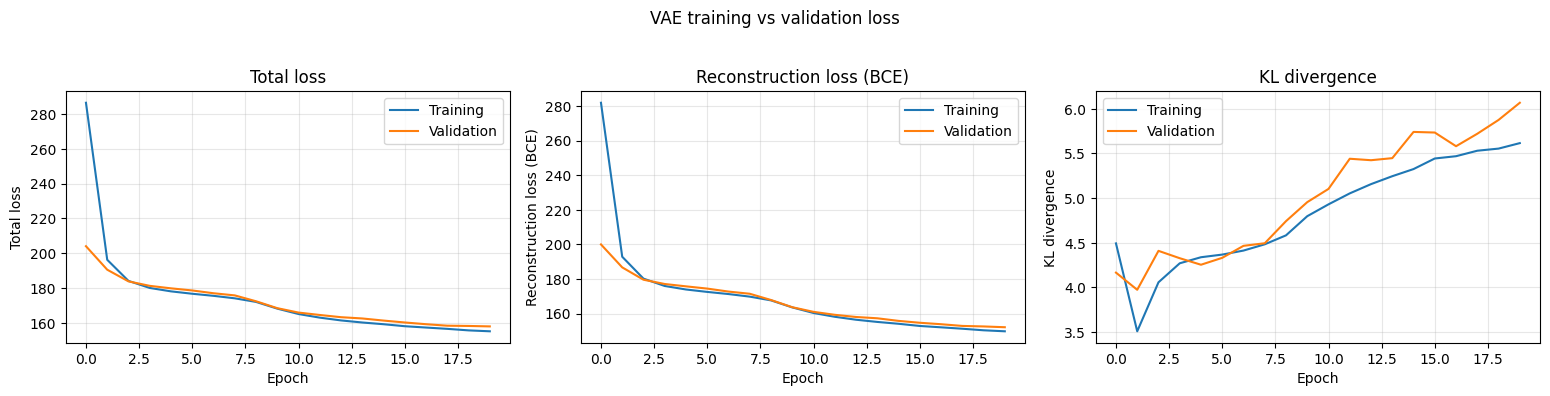

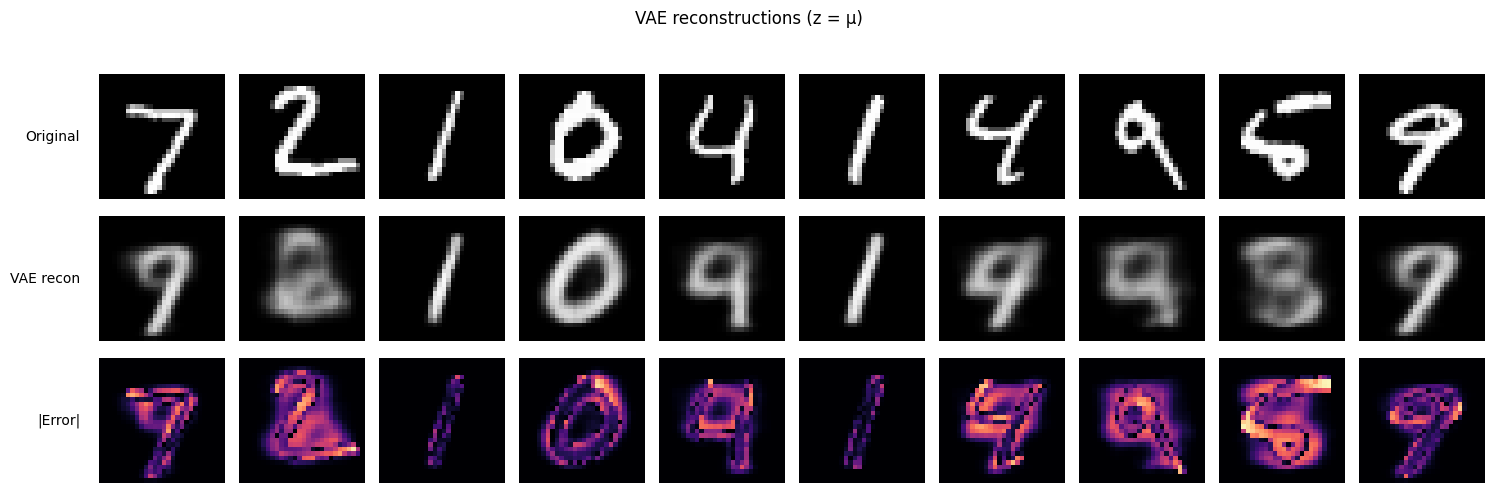

In [12]:
# ---- VAE evaluation on the test set ----
z_mean_t, z_logvar_t, z_samp_t = encoder.predict(x_test, verbose=0)
recon_vae_sampled = decoder.predict(z_samp_t, verbose=0)      # used for the loss (expectation over q(z|x))
recon_vae         = decoder.predict(z_mean_t, verbose=0)      # deterministic recon (z = mu) for images/metrics

def bce_sum(x, xh):
    xh = np.clip(xh, 1e-7, 1 - 1e-7)
    return -np.sum(x * np.log(xh) + (1 - x) * np.log(1 - xh), axis=(1, 2, 3))

rec_loss = float(bce_sum(x_test, recon_vae_sampled).mean())
kl_loss  = float((-0.5 * np.sum(1 + z_logvar_t - z_mean_t**2 - np.exp(z_logvar_t), axis=1)).mean())
mv = evaluate_recon(x_test, recon_vae)
results["VAE"] = {**mv, "Parameters": encoder.count_params() + decoder.count_params(), "Time (s)": t_vae}

vae_table = pd.DataFrame({"VAE Metric": ["Reconstruction Loss (BCE, per image)", "KL Loss (per image)",
                                         "Total Loss", "Test MSE", "Test MAE", "Mean SSIM"],
                          "Value": [rec_loss, kl_loss, rec_loss + kl_loss, mv["MSE"], mv["MAE"], mv["SSIM"]]})
print("=== VAE test metrics (MSE/MAE/SSIM use z = mu) ===")
display(vae_table)

# ---- Plot 9 (list item 9): VAE training / validation loss ----
plot_history(hist_vae, [("total_loss", "val_total_loss", "Total loss"),
                        ("reconstruction_loss", "val_reconstruction_loss", "Reconstruction loss (BCE)"),
                        ("kl_loss", "val_kl_loss", "KL divergence")],
             "plot9_vae_loss", "VAE training vs validation loss")

show_rows([x_test[:10], recon_vae[:10], np.abs(x_test[:10] - recon_vae[:10])], ["Original", "VAE recon", "|Error|"],
          n=10, name="vae_reconstruction", title="VAE reconstructions (z = μ)", cmaps=["gray", "gray", "magma"])

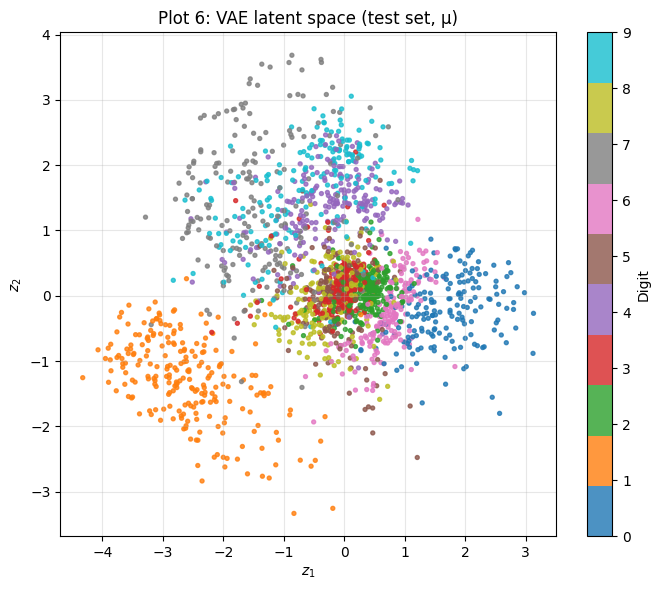

Latent statistics (test set):
  mean of mu   : [-0.313  0.255] | std of mu : [1.267 1.074]   (prior N(0,I) would give ~0 and ~1)
  mean of sigma: [0.071 0.07 ]


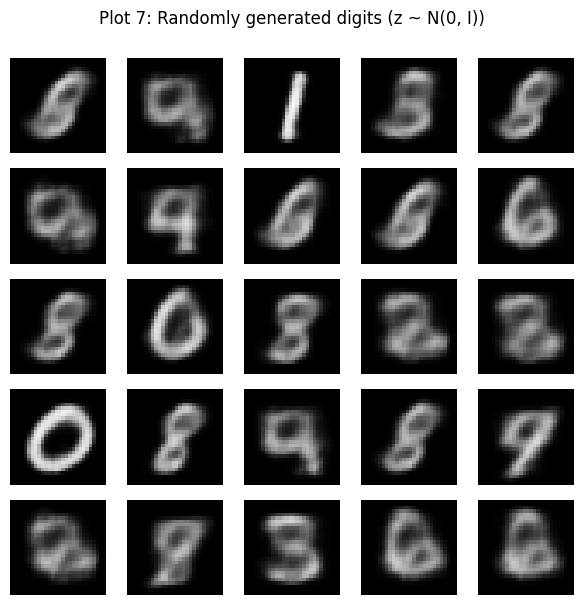

In [13]:
# ---- Plot 6: 2-D latent space coloured by digit label (labels only for visualisation) ----
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(z_mean_t[:, 0], z_mean_t[:, 1], c=y_test, cmap="tab10", s=8, alpha=0.8)
cb = plt.colorbar(sc, ax=ax, ticks=range(10)); cb.set_label("Digit")
ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$"); ax.set_title("Plot 6: VAE latent space (test set, μ)"); ax.grid(alpha=.3)
finish("plot6_vae_latent_space")

print("Latent statistics (test set):")
print(f"  mean of mu   : {z_mean_t.mean(0).round(3)} | std of mu : {z_mean_t.std(0).round(3)}   (prior N(0,I) would give ~0 and ~1)")
print(f"  mean of sigma: {np.exp(0.5*z_logvar_t).mean(0).round(3)}")

# ---- Plot 7: 25 random samples z ~ N(0, I) ----
rs = np.random.default_rng(SEED)
z_rand = rs.standard_normal((25, LATENT_VAE)).astype("float32")
gen = decoder.predict(z_rand, verbose=0)
fig, axes = plt.subplots(5, 5, figsize=(6, 6))
for a, img in zip(axes.ravel(), gen):
    a.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1); a.axis("off")
fig.suptitle("Plot 7: Randomly generated digits (z ~ N(0, I))", y=1.0)
finish("plot7_vae_generated")

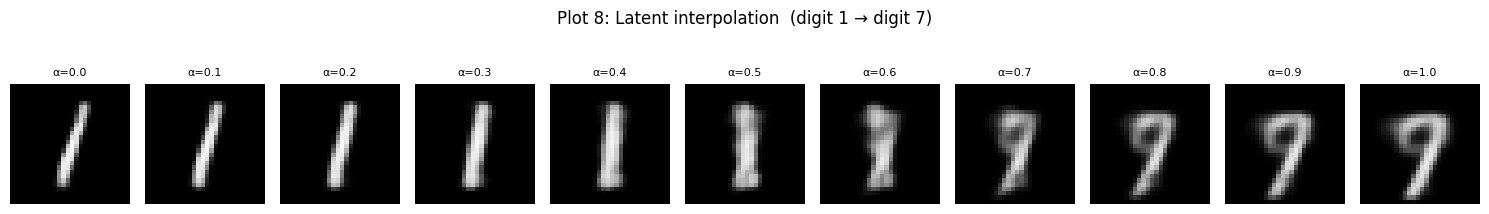

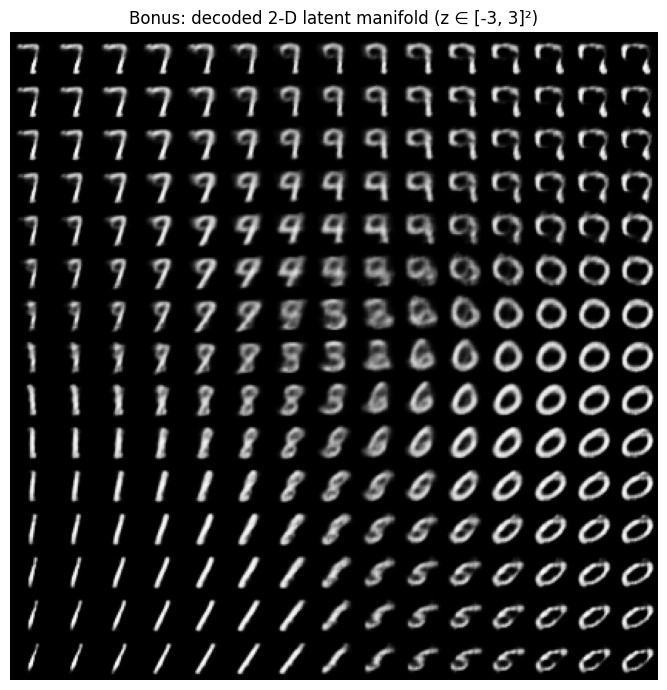

In [14]:
# ---- Plot 8: latent-space interpolation z(a) = (1-a) zA + a zB ----
DIGIT_A, DIGIT_B = 1, 7          # <- change to interpolate between any two digit classes
idxA = int(np.where(y_test == DIGIT_A)[0][0]); idxB = int(np.where(y_test == DIGIT_B)[0][0])
zA, zB = z_mean_t[idxA], z_mean_t[idxB]
alphas = np.linspace(0, 1, 11)
z_int = np.array([(1 - a) * zA + a * zB for a in alphas], dtype="float32")
interp = decoder.predict(z_int, verbose=0)

fig, axes = plt.subplots(1, 11, figsize=(15, 1.9))
for a, img, al in zip(axes, interp, alphas):
    a.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1); a.axis("off"); a.set_title(f"α={al:.1f}", fontsize=8)
fig.suptitle(f"Plot 8: Latent interpolation  (digit {DIGIT_A} → digit {DIGIT_B})", y=1.12)
finish("plot8_interpolation")

# ---- Bonus: decoded manifold over a 15x15 grid of the 2-D latent space ----
n_g, lim = 15, 3.0
grid_x = np.linspace(-lim, lim, n_g); grid_y = np.linspace(lim, -lim, n_g)
zz = np.array([[gx, gy] for gy in grid_y for gx in grid_x], dtype="float32")
imgs = decoder.predict(zz, verbose=0).reshape(n_g, n_g, 28, 28)
canvas = imgs.transpose(0, 2, 1, 3).reshape(n_g * 28, n_g * 28)
plt.figure(figsize=(7, 7)); plt.imshow(canvas, cmap="gray"); plt.axis("off")
plt.title("Bonus: decoded 2-D latent manifold (z ∈ [-3, 3]²)")
finish("bonus_vae_manifold")

---
# 8. Reconstruction-Error Distribution and High-Error Images
Per-image error  eᵢ = (1/D) Σⱼ (xᵢⱼ − x̂ᵢⱼ)²  on the test set.

--- FC-AE ---
mean=0.02047 | std=0.01066 | min=0.00188 | max=0.06928
percentiles 5/25/50/75/95: [0.00433 0.01295 0.01937 0.02664 0.03946]


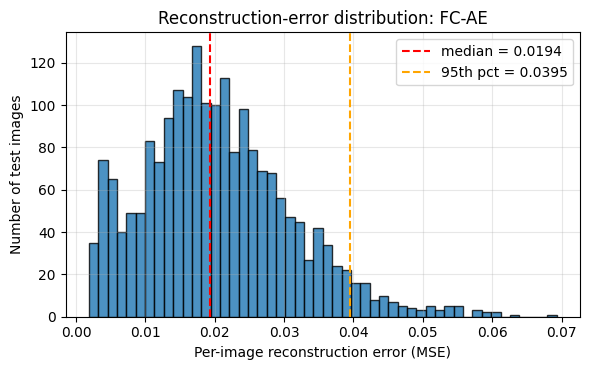

Top-5 highest-error test indices: [1782, 1758, 1170, 744, 338] | digits: [8, 8, 8, 2, 8] | errors: [0.0692799985408783, 0.062780000269413, 0.06102000176906586, 0.06055000051856041, 0.05956000089645386]


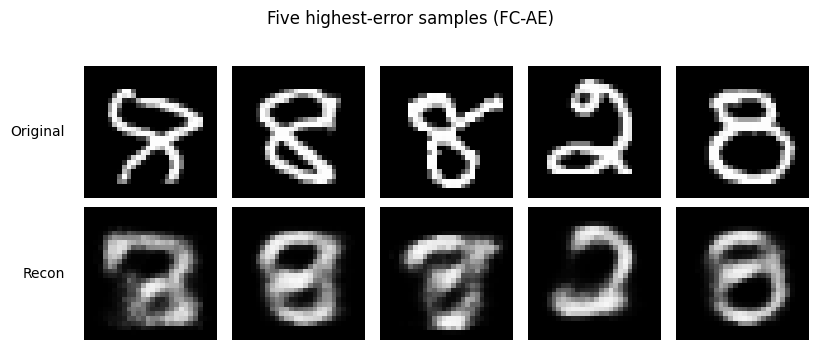

--- CAE ---
mean=0.00259 | std=0.00143 | min=0.00028 | max=0.01198
percentiles 5/25/50/75/95: [0.00066 0.00168 0.00235 0.00331 0.00517]


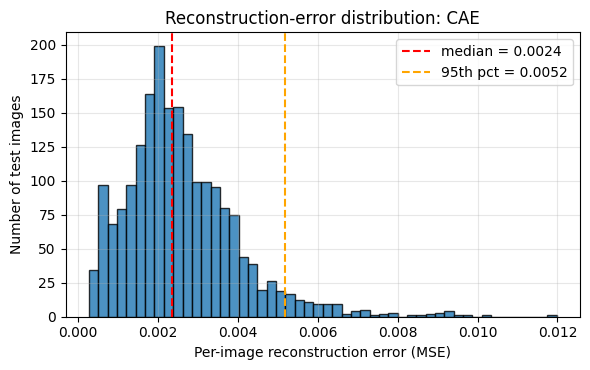

Top-5 highest-error test indices: [895, 1982, 1526, 431, 1908] | digits: [0, 6, 0, 8, 6] | errors: [0.011979999952018261, 0.010230000130832195, 0.009680000133812428, 0.00949000008404255, 0.009309999644756317]


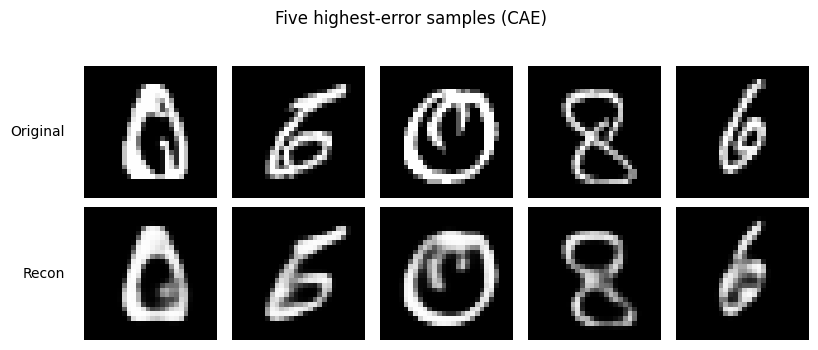

--- VAE (z=μ) ---
mean=0.04476 | std=0.01906 | min=0.00259 | max=0.12215
percentiles 5/25/50/75/95: [0.00785 0.03424 0.04584 0.05634 0.07394]


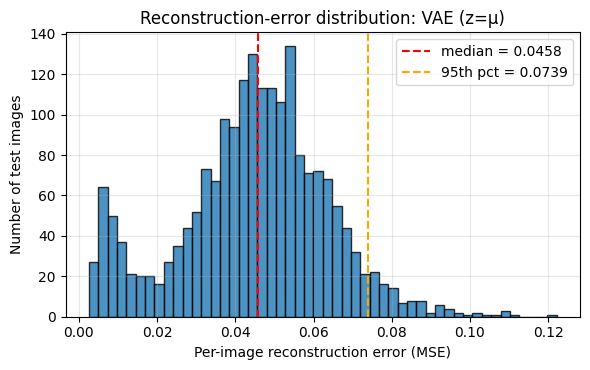

Top-5 highest-error test indices: [1352, 654, 1847, 1790, 1325] | digits: [2, 5, 5, 2, 8] | errors: [0.1221499964594841, 0.11078999936580658, 0.10919000208377838, 0.10903000086545944, 0.10832999646663666]


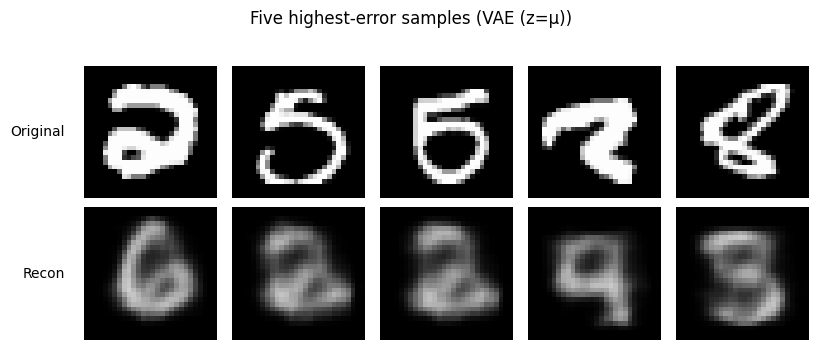

In [15]:
def error_analysis(name, recon, tag):
    e = per_image_mse(x_test, recon)
    q = np.percentile(e, [5, 25, 50, 75, 95])
    print(f"--- {name} ---")
    print(f"mean={e.mean():.5f} | std={e.std():.5f} | min={e.min():.5f} | max={e.max():.5f}")
    print(f"percentiles 5/25/50/75/95: {np.round(q, 5)}")

    # Plot 9 (histogram): distribution of per-image errors
    fig, ax = plt.subplots(figsize=(6, 3.8))
    ax.hist(e, bins=50, edgecolor="k", alpha=.8)
    ax.axvline(np.median(e), color="r", ls="--", label=f"median = {np.median(e):.4f}")
    ax.axvline(np.percentile(e, 95), color="orange", ls="--", label=f"95th pct = {np.percentile(e, 95):.4f}")
    ax.set_xlabel("Per-image reconstruction error (MSE)"); ax.set_ylabel("Number of test images")
    ax.set_title(f"Reconstruction-error distribution: {name}"); ax.legend(); ax.grid(alpha=.3)
    finish(f"plot_error_hist_{tag}")

    # Five worst images
    top5 = np.argsort(e)[::-1][:5]
    print("Top-5 highest-error test indices:", top5.tolist(), "| digits:", y_test[top5].tolist(), "| errors:", np.round(e[top5], 5).tolist())
    show_rows([x_test[top5], recon[top5]], ["Original", "Recon"], n=5,
              name=f"high_error_{tag}", title=f"Five highest-error samples ({name})")
    return e

err_fc  = error_analysis("FC-AE",  recon_fc,  "fc")
err_cae = error_analysis("CAE",    recon_cae, "cae")
err_vae = error_analysis("VAE (z=μ)", recon_vae, "vae")

---
# 9. Consolidated Results

In [16]:
final = pd.DataFrame(results).T[["MSE", "MAE", "SSIM", "Parameters", "Time (s)"]]
final["Parameters"] = final["Parameters"].astype(int)
final["Time (s)"] = final["Time (s)"].round(1)

print("=== Section 21: reconstruction comparison ===")
display(final.loc[["FC Autoencoder", "Conv. Autoencoder", "Denoising CAE"], ["MSE", "MAE", "SSIM", "Parameters"]])
print("\n=== VAE metrics ===")
display(vae_table)
print("\n=== Section 25: consolidated results ===")
display(final.loc[["FC Autoencoder", "Conv. Autoencoder", "Denoising CAE", "VAE"]])
print("\nNote: Denoising CAE metrics = noisy (Gaussian sigma=0.2) input vs clean target. "
      "VAE metrics use z = mu; its total objective also includes the KL term.")

final.to_csv("figures/consolidated_results.csv"); noise_df.to_csv("figures/noise_results.csv", index=False)
lat_df.to_csv("figures/latent_dim_results.csv", index=False); vae_table.to_csv("figures/vae_results.csv", index=False)

=== Section 21: reconstruction comparison ===


,MSE,MAE,SSIM,Parameters
FC Autoencoder,0.02047,0.05513,0.75865,211040
Conv. Autoencoder,0.00259,0.01508,0.97371,74497
Denoising CAE,0.00437,0.02057,0.94717,74497



=== VAE metrics ===


,VAE Metric,Value
0,"Reconstruction Loss (BCE, per image)",151.31702
1,KL Loss (per image),5.95131
2,Total Loss,157.26833
3,Test MSE,0.04476
4,Test MAE,0.10552
5,Mean SSIM,0.48419



=== Section 25: consolidated results ===


,MSE,MAE,SSIM,Parameters,Time (s)
FC Autoencoder,0.02047,0.05513,0.75865,211040,12.20000
Conv. Autoencoder,0.00259,0.01508,0.97371,74497,20.70000
Denoising CAE,0.00437,0.02057,0.94717,74497,29.30000
VAE,0.04476,0.10552,0.48419,485957,24.90000



Note: Denoising CAE metrics = noisy (Gaussian sigma=0.2) input vs clean target. VAE metrics use z = mu; its total objective also includes the KL term.


In [17]:
# ---- Zip all figures + CSV tables for your report ----
with zipfile.ZipFile("exp7_outputs.zip", "w") as zf:
    for f in sorted(os.listdir("figures")):
        zf.write(os.path.join("figures", f))
print("Saved:", len(os.listdir("figures")), "files ->", "exp7_outputs.zip")
try:
    from google.colab import files
    files.download("exp7_outputs.zip")
except Exception as ex:
    print("Download manually from the Files panel on the left.", ex)

Saved: 25 files -> exp7_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
# 10. Inference Templates (fill in from YOUR plots/tables)
For every plot, write four things: **(1) What it shows · (2) Trend · (3) Why · (4) Conclusion.**

| # | Mandatory inference | Look at | Points to address |
|---|---|---|---|
| 1 | Effect of latent dimension | Plot 10 + table | MSE falls / SSIM rises as dz grows; diminishing returns beyond ~16; dz=2 loses fine detail (compression vs quality trade-off) |
| 2 | FC vs Conv reconstruction | Plot 3 + table | Compare MSE/SSIM/params; convolutions share weights and keep spatial locality, so strokes and edges stay sharper |
| 3 | Effect of Gaussian noise | Plot 5 (Gaussian) | Error rises and SSIM drops with σ; compare denoised vs noisy curves |
| 4 | DAE recovering structure | Plot 4 + Plot 5 | Does denoised SSIM beat noisy SSIM at every level? Is the digit identity still clear? Note residual blur |
| 5 | VAE latent distribution | Latent stats printed under Plot 6 | Are μ ≈ 0 and σ close to 1 overall (KL pulls towards the prior N(0, I))? |
| 6 | 2-D latent structure | Plot 6 | Same-digit clusters? Which digits overlap (e.g. 4/9, 3/5/8)? Is the space continuous with no big gaps? |
| 7 | Generated quality/diversity | Plot 7 + bonus manifold | Recognisable digits? Variety? Ambiguous or blurry samples (usually between clusters)? |
| 8 | Interpolation smoothness | Plot 8 | Gradual morph vs abrupt jumps; intermediate images that look like other digits |
| 9 | Error vs visual quality | Error histogram + top-5 images | Typical range, long tail, high-error samples are unusual styles, thick/slanted or ambiguous strokes |
| 10 | Deterministic vs probabilistic latent | FC-AE vs VAE | AE: point code, better reconstruction, no guarantee of a smooth/generative space; VAE: distribution + KL regulariser, smoother space, can generate, slightly blurrier reconstructions |

**Overfitting check (Plot 2):** compare final train vs validation loss (printed under the plot). A small, stable gap with both curves flattening means it converges without notable overfitting.

---
# 11. Discussion Questions – Short Answers
1. **Autoencoder:** a network trained to reproduce its input through a lower-dimensional bottleneck (encoder → latent → decoder).
2. **Encoder:** compresses the input x into a compact latent code z = f(x), keeping the most useful information.
3. **Decoder:** reconstructs x̂ = g(z) from the latent code.
4. **Latent representation:** the compressed internal code z that summarises the input.
5. **Why smaller:** the bottleneck forces the model to learn essential structure instead of copying the input (otherwise it could learn the identity map).
6. **Latent too small:** information is lost, so reconstructions become blurry and digits can be confused (underfitting).
7. **Latent increased:** reconstruction improves with diminishing returns; too large a code can approach an identity map and learn less useful features.
8. **CAE and spatial info:** convolutions use local receptive fields and shared weights, so neighbouring-pixel structure and translation patterns are preserved with far fewer parameters than dense layers.
9. **AE vs DAE:** an AE reconstructs its own clean input, while a DAE receives a corrupted input and must reconstruct the clean one.
10. **Clean target in denoising:** the loss must reward removing noise; with a noisy target the model would learn to reproduce noise.
11. **Higher noise:** MSE/MAE rise and SSIM falls; fine strokes are lost and reconstructions get blurrier.
12. **MSE, MAE, SSIM:** MSE penalises large pixel errors, MAE measures average absolute error (robust to outliers), SSIM measures perceptual/structural similarity (luminance, contrast, structure), which pixel errors alone miss.
13. **VAE:** a generative autoencoder that encodes inputs as probability distributions q(z|x) and regularises them towards a prior.
14. **VAE vs AE:** the VAE encoder outputs (μ, log σ²) and samples z, and its loss adds a KL term; the AE gives a single deterministic z and only a reconstruction loss.
15. **Distribution vs single vector:** it makes nearby latent points decode to similar images and fills the latent space smoothly, enabling sampling and generation.
16. **Reparameterisation trick:** write z = μ + σ ⊙ ε with ε ~ N(0, I), moving the randomness into ε so gradients flow through μ and σ.
17. **ε standard normal:** it is parameter-free (so it does not block gradients) and gives z the intended mean μ and variance σ², matching the N(0, I) prior.
18. **KL role:** it pulls each q(z|x) towards N(0, I), keeping the latent space compact and continuous so random sampling gives valid images; too large a weight blurs reconstructions.
19. **Prior:** p(z) = N(0, I).
20. **2-D latent:** it can be plotted directly, so clusters, overlaps and the structure of the latent space can be inspected visually.
21. **Interpolation:** it shows whether the latent space is smooth and continuous, with gradual morphing between two digits.
22. **Why VAE generates:** the latent space is regularised to follow N(0, I), so sampling from that prior and decoding gives plausible new images.
23. **Unclear samples:** points may fall between clusters or in low-density regions, and the KL term and small latent size cause blurry averaging.
24. **Reconstruction vs generation:** reconstruction encodes a real image then decodes it; generation decodes a latent vector sampled from the prior with no input image.
25. **Unseen test images:** to measure true generalisation. Evaluating on training images would hide overfitting and inflate performance.